# Explanatory Model Analysis (with XGBoost)

In [1]:
import os
import json
import pandas as pd
import numpy as np
import joblib
import shap
import pickle
import matplotlib.pyplot as plt

if not hasattr(np, "in1d"):
    np.in1d = np.isin

import xgboost
import dalex as dx
from pathlib import Path
from copy import deepcopy
from xgboost import XGBClassifier
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, fbeta_score, f1_score, recall_score, precision_score, precision_recall_curve, auc, average_precision_score
from src.utils.data_fetch import DataLoader
from src.stats import compare_adjacent_models
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix

import seaborn as sns

D:\Projects\ds207_final_project\ds207_final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Projects\ds207_final_project\ds207_final_project\.venv\Lib\site-packages\dalex\_global_checks.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
D:\Projects\ds207_final_project\ds207_final_project\.venv\Lib\site-packages\dalex\_explainer\helper.py:16: SyntaxWarning: invalid escape sequence '\.'
  model_package = re.search("(?<=<class ').*?(?=\.)", str(type(model)))[0]


### Settings

In [2]:
# Settings -------------------------------------------------------------------------------------------

SEED = 1234
PATH_XGB = Path('gradient_boosting')
PATH_TE_DATA = Path('../data/extra/target_encoded')
PATH_LABEL_MAP = Path('../data/final_processed/base_kf/label/label_map.json')
PATH_XGB_ANALYSIS = Path('../data/extra/analysis')
# PATH_ROOT = Path(os.getcwd())
# PATH_XGB = PATH_ROOT / r'notebook\gradient_boosting'
# PATH_TE_DATA = PATH_ROOT / r'data\extra\target_encoded'
# PATH_LABEL_MAP = PATH_ROOT / r'data\final_processed\base_kf\label\label_map.json'
# PATH_XGB_ANALYSIS = PATH_ROOT / r'data\extra\analysis'

# Model code and the corresponding model name prefix to load
DICT_PREFIX = {
    "m0": "xgboost_onehot",
    "m1": "xgboost_num",
    "m2": "xgboost_num_dem",
    "m3": "xgboost_num_dem_clin",
    "m4": "xgboost_num_dem_clin_diag",
    "m5": "xgboost_num_dem_clin_diag_druggrp",
    "m6": "xgboost_label",
    "m7": "xgboost_full_te_clin",
    "m8": "xgboost_full_te_clin_diag",
    "m9": "xgboost_full_te_clin_diag_other",
    # 'm10': 'xgboost_final',
}
TUNE_METRIC = 'prauc' # recall/auc/f1/f2/prauc

# XGBoost training output holder
DICT_PATH_PARAM        = {k: v + '_' + f'params_{TUNE_METRIC}.json' for k, v in DICT_PREFIX.items()}
DICT_PATH_LOG_OUTPUT   = {k: v + '_' + f'log_{TUNE_METRIC}.csv' for k    , v in DICT_PREFIX.items()}
DICT_PATH_PROB_OUTPUT  = {k: v + '_' + f'prob_{TUNE_METRIC}.json' for k  , v in DICT_PREFIX.items()}
DICT_PATH_MODEL_OUTPUT = {k: v + '_' + f'model_{TUNE_METRIC}.json' for k , v in DICT_PREFIX.items()}

# Generic XGBoost training param
fixed_params = {
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'logloss',
    'tree_method'       : 'hist',
    'device'            : 'cpu',
    'enable_categorical': True,
    'random_state'      : SEED,
    'n_jobs'            : -1,
}

# Reference feature combination holder
DICT_FEATURE = dict()

### Load outputs from XGBoost training (see notebook/gradient_boosting)

In [3]:
# Load Outputs -------------------------------------------------------------------------------------------

# Tuning log
DICT_LOG_OUTPUT = {k: pd.read_csv(PATH_XGB / v) for k, v in DICT_PATH_LOG_OUTPUT.items()}

# Tuned model
DICT_MODEL_OUTPUT = {k: joblib.load(PATH_XGB / v) for k, v in DICT_PATH_MODEL_OUTPUT.items()}

# Tuned probability threshold
DICT_PROB_OUTPUT = dict()
for k, v in DICT_PATH_PROB_OUTPUT.items():
    with open(PATH_XGB / v, 'r') as f:
        DICT_PROB_OUTPUT[k] = json.load(f)['best_th']

# Tuned parameters
DICT_PARAM = dict()
for k, v in DICT_PATH_PARAM.items():
    with open(PATH_XGB / v, 'r') as f:
        best_params = json.load(f)
    final_params = deepcopy(fixed_params)
    final_params.update(best_params)
    final_params.update({"device": "cpu"})
    DICT_PARAM[k] = final_params


C:\Users\USER\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\pickle.py:1760: UserWarning: [17:28:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:384: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  setstate(state)
C:\Users\USER\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\pickle.py:1760: UserWarning: [17:28:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:49: No visible GPU is found, setting device to CPU.
  setstate(state)
C:\Users\USER\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\pickle.py:1760: UserWarning: [17:28:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:203: XGBoost is not compiled with CUDA support.
  setstate(state)


### Load and preprocess data

In [4]:

# Load and Preprocess Data -------------------------------------------------------------------------------------------

# Load data
X_train, X_val, X_test, y_train, y_val, y_test = DataLoader().fetch_data(version='final_raw')
X_train_label, X_val_label, X_test_label, _, _, _ = DataLoader().fetch_data(version='final_label')
X_train_oh, X_val_oh, X_test_oh, _, _, _ = DataLoader().fetch_data(version='final_onehot')
X_train_interim, X_val_interim, X_test_interim, _, _, _ = DataLoader().fetch_data(version='interim')
df_raw = pd.concat([X_train_interim, X_val_interim, X_test_interim], axis=0, ignore_index=True)

# Update one-hot data columns
cols_update = [c.replace('[', '(').replace(')', ')').replace('<', 'lt').replace('>', 'gt') for c in X_train_oh.columns]
X_train_oh.columns = cols_update
X_val_oh.columns = cols_update
X_test_oh.columns = cols_update

# Define columns
id_cols = [
    'pipeline_raw__encounter_id'
]
num_cols = [
    'pipeline_standard__time_in_hospital',
    'pipeline_standard__num_lab_procedures',
    'pipeline_standard__num_procedures',
    'pipeline_standard__num_medications',
    'pipeline_standard__number_outpatient',
    'pipeline_standard__number_emergency',
    'pipeline_standard__number_inpatient',
    'pipeline_standard__number_diagnoses'
]
dem_cols = [
    'pipeline_raw__race',
    'pipeline_raw__gender',
    'pipeline_raw__age',
]
clin_cols = [
    'pipeline_raw__max_glu_serum',
    'pipeline_raw__A1Cresult',
    'pipeline_admission_type_raw__admission_type_id',
    'pipeline_discharge_raw__discharge_disposition_id',
    'pipeline_admission_src_raw__admission_source_id',
    'pipeline_medical_raw__medical_specialty',
]
diag_cols = [
    'pipeline_icd9_raw__diag_1',
    'pipeline_icd9_raw__diag_2',
    'pipeline_icd9_raw__diag_3',
]
druggrp_cols = [
    'pipeline_prescript_raw__sulfonylureas__prescribed',
    'pipeline_prescript_raw__sulfonylureas__change',
    'pipeline_prescript_raw__tzds__prescribed',
    'pipeline_prescript_raw__tzds__change',
    'pipeline_prescript_raw__meglitinides__prescribed',
    'pipeline_prescript_raw__meglitinides__change',
    'pipeline_prescript_raw__alpha_glucosidase__prescribed',
    'pipeline_prescript_raw__alpha_glucosidase__change',
    'pipeline_prescript_raw__metformin__prescribed',
    'pipeline_prescript_raw__metformin__change',
    'pipeline_prescript_raw__insulin__prescribed',
    'pipeline_prescript_raw__insulin__change',
]
drug_cols = [
    'pipeline_prescript_raw__metformin',
    'pipeline_prescript_raw__repaglinide',
    'pipeline_prescript_raw__nateglinide',
    'pipeline_prescript_raw__chlorpropamide',
    'pipeline_prescript_raw__glimepiride',
    'pipeline_prescript_raw__acetohexamide',
    'pipeline_prescript_raw__glipizide',
    'pipeline_prescript_raw__glyburide',
    'pipeline_prescript_raw__tolbutamide',
    'pipeline_prescript_raw__pioglitazone',
    'pipeline_prescript_raw__rosiglitazone',
    'pipeline_prescript_raw__acarbose',
    'pipeline_prescript_raw__miglitol',
    'pipeline_prescript_raw__troglitazone',
    'pipeline_prescript_raw__tolazamide',
    'pipeline_prescript_raw__insulin',
    'pipeline_prescript_raw__glyburide-metformin',
    'pipeline_prescript_raw__glipizide-metformin',
    'pipeline_prescript_raw__glimepiride-pioglitazone',
    'pipeline_prescript_raw__metformin-rosiglitazone',
    'pipeline_prescript_raw__metformin-pioglitazone',
]
diag_te_cols  = [
    'diag_1_te',
    'diag_2_te',
    'diag_3_te',
]
clin_te_cols = [
    'medical_specialty_te',
    'admission_source_id_te',
    'admission_type_id_te',
    'discharge_disposition_id_te',
]
other_cols = [
    'weight',
    'payer_code'
]
num_cols_raw = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Drop columns
X_train    = X_train.drop(id_cols + num_cols_raw, axis = 1)
X_val      = X_val.drop(id_cols + num_cols_raw  , axis = 1)
X_test     = X_test.drop(id_cols + num_cols_raw , axis = 1)
X_train_oh = X_train_oh.drop(id_cols            , axis = 1)
X_val_oh   = X_val_oh.drop(id_cols              , axis = 1)
X_test_oh  = X_test_oh.drop(id_cols             , axis = 1)

# Use standardize numerical columns in raw
X_train[num_cols] = X_train_label[num_cols]
X_val[num_cols] = X_val_label[num_cols]
X_test[num_cols] = X_test_label[num_cols]

# Add target encoded columns
X_train_te = pd.read_csv(PATH_TE_DATA / "X_train_te.csv")
X_val_te   = pd.read_csv(PATH_TE_DATA / "X_val_te.csv")
X_test_te  = pd.read_csv(PATH_TE_DATA / "X_test_te.csv")
X_train[clin_te_cols + diag_te_cols] = X_train_te[clin_te_cols + diag_te_cols]
X_val[clin_te_cols + diag_te_cols]   = X_val_te[clin_te_cols + diag_te_cols]
X_test[clin_te_cols + diag_te_cols]  = X_test_te[clin_te_cols + diag_te_cols]

# Add other columns (weight, payer_code)
df_raw['payer_code'] = df_raw['payer_code'].replace('?'   , np.nan).fillna('Unknown').astype('category')
df_raw['weight']     = df_raw['weight'].replace('?'       , np.nan).fillna('Unknown').astype('category')
all_payer_code       = df_raw['payer_code'].cat.categories
all_weight           = df_raw['weight'].cat.categories

X_train['payer_code'] = pd.Categorical(X_train_interim['payer_code'].replace('?', np.nan).fillna('Unknown'), categories = all_payer_code)
X_val['payer_code']   = pd.Categorical(X_val_interim['payer_code'].replace('?'  , np.nan).fillna('Unknown'), categories = all_payer_code)
X_test['payer_code']  = pd.Categorical(X_test_interim['payer_code'].replace('?' , np.nan).fillna('Unknown'), categories = all_payer_code)
X_train['weight']     = pd.Categorical(X_train_interim['weight'].replace('?'    , np.nan).fillna('Unknown'), categories = all_weight)
X_val['weight']       = pd.Categorical(X_val_interim['weight'].replace('?'      , np.nan).fillna('Unknown'), categories = all_weight)
X_test['weight']      = pd.Categorical(X_test_interim['weight'].replace('?'     , np.nan).fillna('Unknown'), categories = all_weight)

# Convert categorical columns type
cat_cols = [c for c in X_train.columns if c not in num_cols + druggrp_cols + clin_te_cols + diag_te_cols]
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_val[cat_cols]   = X_val[cat_cols].astype('category')
X_test[cat_cols]  = X_test[cat_cols].astype('category')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_test.csv 
Data imported succesfully from paths
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project

### Feature combinations for each model (reference only)

In [5]:
# Populate column dictionary for each model (for illustration purpose only, not used)
DICT_FEATURE['m0'] = X_train_oh.columns.tolist()
DICT_FEATURE['m1'] = num_cols
DICT_FEATURE['m2'] = num_cols + dem_cols
DICT_FEATURE['m3'] = num_cols + dem_cols + clin_cols
DICT_FEATURE['m4'] = num_cols + dem_cols + clin_cols + diag_cols
DICT_FEATURE['m5'] = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols
DICT_FEATURE['m6'] = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols + drug_cols
DICT_FEATURE['m7'] = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols + drug_cols + clin_te_cols
DICT_FEATURE['m8'] = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols + drug_cols + clin_te_cols + diag_te_cols
DICT_FEATURE['m9'] = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols + drug_cols + clin_te_cols + diag_te_cols + other_cols
# DICT_FEATURE['m10'] = ...

DICT_ADDED_FEATURES = dict()
DICT_ADDED_FEATURES['m0'] = 'One-Hot (Reference Only)'
DICT_ADDED_FEATURES['m1'] = 'Numerical (Raw, Baseline)'
DICT_ADDED_FEATURES['m2'] = 'Demographics (Raw)'
DICT_ADDED_FEATURES['m3'] = 'Clinical (Grouped)'
DICT_ADDED_FEATURES['m4'] = 'Diagnosis (Grouped)'
DICT_ADDED_FEATURES['m5'] = 'Prescription Statistics (Grouped)'
DICT_ADDED_FEATURES['m6'] = 'Prescription (Raw)'
DICT_ADDED_FEATURES['m7'] = 'Clinical (Raw, Target Encoded)'
DICT_ADDED_FEATURES['m8'] = 'Diagnosis (Raw, Target Encoded)'
DICT_ADDED_FEATURES['m9'] = 'Payer Code & Weight (Raw)'

### Section running flags

In [6]:
RUN_ONEHOT_IMP = False
RUN_PREDICTIVE_CONTRI = False
RUN_FEATURE_GROUP_IMP_CONCEPT = False
RUN_FEATURE_GROUP_IMP_REP = False
RUN_SHAP_IMPORTANCE = False
RUN_SHAP_GROUP = False
RUN_SHAP_INTERACTION = False
RUN_SHAP_DEPENDENCY = False
RUN_RESIDUAL_ANA = False

### Analysis 0: XGBoost model importance score (one-hot vs label encoded validation data)

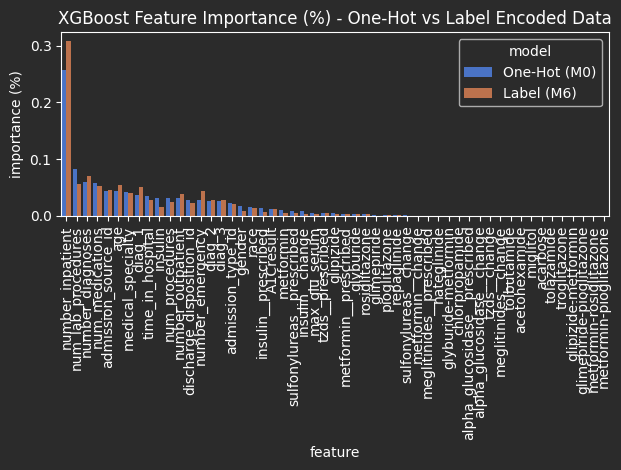

In [12]:
# 0. Loss Importance (One-Hot vs Label) -------------------------------------------------------------------------------------------

ls_col_raw = num_cols + dem_cols + clin_cols + diag_cols + druggrp_cols + drug_cols
ls_col_oh = [c.replace('_raw', '') for c in ls_col_raw]

model_oh = DICT_MODEL_OUTPUT['m0']
model_raw = DICT_MODEL_OUTPUT['m6']

if RUN_ONEHOT_IMP:

    # Get One-Hot feature importance
    dict_imp_oh = {
        'gain': model_oh.get_booster().get_score(importance_type='gain'),
        'total_gain': model_oh.get_booster().get_score(importance_type='total_gain'),
        'weight': model_oh.get_booster().get_score(importance_type='weight'),
        'cover': model_oh.get_booster().get_score(importance_type='cover'),
        'total_cover': model_oh.get_booster().get_score(importance_type='total_cover'),
    }
    df_imp_oh = pd.concat([pd.DataFrame(v, index=[k]).T for k, v in dict_imp_oh.items()], axis=1).sort_values('total_gain', ascending=False)
    df_imp_oh.index = [idx.replace('_onehot', '') for idx in df_imp_oh.index]
    dict_imp_oh_count = dict()
    for c in ls_col_oh:
        dict_imp_oh_count[c] = 0.
    for c in ls_col_oh:     # Drug group first then drug to avoid mismatch
        dict_imp_oh_count[c] = df_imp_oh.loc[[c in idx for idx in df_imp_oh.index]]['total_gain'].sum()
    df_imp_oh_count = pd.DataFrame(dict_imp_oh_count, index=[0]).T
    df_imp_oh_count[0] = df_imp_oh_count[0] / df_imp_oh_count[0].sum()
    df_imp_oh_count.index = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_imp_oh_count.index]
    df_imp_oh_count = df_imp_oh_count.reset_index(drop=False)
    df_imp_oh_count.columns = ['feature', 'importance (%)']
    df_imp_oh_count['model'] = 'One-Hot (M0)'
    df_imp_oh_count.sort_values('importance (%)', ascending=False, inplace=True)

    # Get label feature importance
    dict_imp_raw = {
        'gain': model_raw.get_booster().get_score(importance_type='gain'),
        'total_gain': model_raw.get_booster().get_score(importance_type='total_gain'),
        'weight': model_raw.get_booster().get_score(importance_type='weight'),
        'cover': model_raw.get_booster().get_score(importance_type='cover'),
        'total_cover': model_raw.get_booster().get_score(importance_type='total_cover'),
    }
    df_imp_raw = pd.concat([pd.DataFrame(v, index=[k]).T for k, v in dict_imp_raw.items()], axis=1).sort_values('total_gain', ascending=False)
    df_imp_raw_count = df_imp_raw.reindex(index=ls_col_raw, fill_value=0)[['total_gain']]
    df_imp_raw_count['total_gain'] = df_imp_raw_count['total_gain'] / df_imp_raw_count['total_gain'].sum()
    df_imp_raw_count.index = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_imp_raw_count.index]
    df_imp_raw_count = df_imp_raw_count.reset_index(drop=False)
    df_imp_raw_count.columns = ['feature', 'importance (%)']
    df_imp_raw_count['model'] = 'Label (M6)'
    df_imp_raw_count.sort_values('importance (%)', ascending=False, inplace=True)

    df_imp_all = pd.concat([df_imp_oh_count, df_imp_raw_count], axis=0, ignore_index=True)

    df_imp_all.to_csv(PATH_XGB_ANALYSIS / 'ana0_onehot_label_imp.csv', index=False)

else:
    df_imp_all = pd.read_csv(PATH_XGB_ANALYSIS / 'ana0_onehot_label_imp.csv')

ax = sns.barplot(df_imp_all, x='feature', y='importance (%)', hue='model')
ax.set_title('XGBoost Feature Importance (%) - One-Hot vs Label Encoded Data')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Analysis 1: Predictive performance analysis

In [13]:
# 1. Predictive Contribution -------------------------------------------------------------------------------------------

if RUN_PREDICTIVE_CONTRI:

    ls_perf_train = []
    ls_perf_val = []
    dict_prob = dict()

    # Get predictive performances using validation data
    for k, model in DICT_MODEL_OUTPUT.items():

        print(k)

        features = model.feature_names_in_
        if k == 'm0':
            y_prob_train = model.predict_proba(X_train_oh[features])[:, 1]
            y_pred_train = model.predict(X_train_oh[features])
            y_prob_val = model.predict_proba(X_val_oh[features])[:, 1]
            y_pred_val = model.predict(X_val_oh[features])
        else:
            y_prob_train = model.predict_proba(X_train[features])[:, 1]
            y_pred_train = model.predict(X_train[features])
            y_prob_val = model.predict_proba(X_val[features])[:, 1]
            y_pred_val = model.predict(X_val[features])

        dict_perf_train = dict(
            model        = k,
            new_features = DICT_ADDED_FEATURES[k],
            recall       = recall_score(y_train           , y_pred_train),
            precision    = precision_score(y_train        , y_pred_train),
            accuracy     = accuracy_score(y_train         , y_pred_train),
            roc_auc      = roc_auc_score(y_train          , y_prob_train),
            prauc        = average_precision_score(y_train, y_prob_train),
            f1           = f1_score(y_train               , y_pred_train),
            f2           = fbeta_score(y_train            , y_pred_train , beta = 2),
        )
        ls_perf_train.append(dict_perf_train)

        dict_perf_val = dict(
            model        = k,
            new_features = DICT_ADDED_FEATURES[k],
            recall       = recall_score(y_val           , y_pred_val),
            precision    = precision_score(y_val        , y_pred_val),
            accuracy     = accuracy_score(y_val         , y_pred_val),
            roc_auc      = roc_auc_score(y_val          , y_prob_val),
            prauc        = average_precision_score(y_val, y_prob_val),
            f1           = f1_score(y_val               , y_pred_val),
            f2           = fbeta_score(y_val            , y_pred_val , beta = 2),
        )
        ls_perf_val.append(dict_perf_val)

        dict_prob[k] = y_prob_val

    df_perf_train = pd.DataFrame(ls_perf_train)
    df_perf_train['d_prauc'] = df_perf_train['prauc'].diff()
    df_perf_train.loc[df_perf_train['model'].isin(['m0', 'm1']), 'd_prauc'] = np.nan
    df_perf_train.set_index('model', inplace=True)
    df_perf_train.to_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_train.csv')

    df_perf_val = pd.DataFrame(ls_perf_val)
    df_perf_val['d_prauc'] = df_perf_val['prauc'].diff()
    df_perf_val.loc[df_perf_val['model'].isin(['m0', 'm1']), 'd_prauc'] = np.nan
    df_perf_val.set_index('model', inplace=True)
    df_perf_val.to_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_val.csv')

    # Get PRAUC comparisons
    df_prauc = compare_adjacent_models(y_val.values, dict_prob, n_bootstrap=5000, random_state=42)
    df_prauc.set_index('comparison', inplace=True)
    df_prauc.to_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_prauc.csv')

else:
    df_perf_train = pd.read_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_train.csv', index_col=0)
    df_perf_val = pd.read_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_val.csv', index_col=0)
    df_prauc = pd.read_csv(PATH_XGB_ANALYSIS / 'ana1_perf_contri_prauc.csv', index_col=0)

print('Performance Assessment (Training Data)')
print(df_perf_train)
print('\n')

print('Performance Assessment (Validation Data)')
print(df_perf_val)
print('\n')

print('PR-AUC Bootstrapping Analysis (Validation Data)')
print(df_prauc)
print('\n')


Performance Assessment (Training Data)
                            new_features    recall  precision  accuracy  \
model                                                                     
m0              One-Hot (Reference Only)  0.536312   0.702822  0.674608   
m1             Numerical (Raw, Baseline)  0.487718   0.641716  0.630249   
m2                    Demographics (Raw)  0.501210   0.647727  0.636473   
m3                    Clinical (Grouped)  0.603346   0.659481  0.666253   
m4                   Diagnosis (Grouped)  0.657387   0.642586  0.666219   
m5     Prescription Statistics (Grouped)  0.636419   0.689486  0.693583   
m6                    Prescription (Raw)  0.605981   0.652384  0.662142   
m7        Clinical (Raw, Target Encoded)  0.594838   0.699297  0.688516   
m8       Diagnosis (Raw, Target Encoded)  0.631435   0.717255  0.709001   
m9             Payer Code & Weight (Raw)  0.593307   0.713870  0.696267   

        roc_auc     prauc        f1        f2   d_prauc  
mo

### Analysis 2: Feature importance analysis (by permutation on feature groups)

In [15]:
# 2. Concept (Feature Group) Importance -------------------------------------------------------------------------------------------

# Define prediction function
def predict_positive_prob(model, data):
    data = data.loc[:, model.feature_names_in_]
    return model.predict_proba(data)[:, 1]

# Define metric
def negative_prauc(obs, pred):
    return -average_precision_score(obs, pred)

# Define feature groups
group_visit = [
    "pipeline_standard__number_outpatient",
    "pipeline_standard__number_emergency",
    "pipeline_standard__number_inpatient",
]
group_hosp_util = [
    'pipeline_standard__time_in_hospital',
    'pipeline_standard__num_lab_procedures',
    'pipeline_standard__num_procedures',
    'pipeline_standard__num_medications',
    'pipeline_standard__number_diagnoses'
]
group_clin_assess = [
    'pipeline_raw__max_glu_serum',
    'pipeline_raw__A1Cresult',
]
group_clin_ops = [
    'pipeline_admission_type_raw__admission_type_id',
    'pipeline_discharge_raw__discharge_disposition_id',
    'pipeline_admission_src_raw__admission_source_id',
    'pipeline_medical_raw__medical_specialty',
]
group_clin_te = [
    'medical_specialty_te',
    'admission_source_id_te',
    'admission_type_id_te',
    'discharge_disposition_id_te',
]
group_diag = [
    "pipeline_icd9_raw__diag_1",
    "pipeline_icd9_raw__diag_2",
    "pipeline_icd9_raw__diag_3",
]
group_diag_te = [
    "diag_1_te",
    "diag_2_te",
    "diag_3_te",
]
group_med_change = [
    "pipeline_prescript_raw__sulfonylureas__change",
    "pipeline_prescript_raw__tzds__change",
    "pipeline_prescript_raw__meglitinides__change",
    "pipeline_prescript_raw__alpha_glucosidase__change",
    "pipeline_prescript_raw__metformin__change",
    "pipeline_prescript_raw__insulin__change",
]
group_med_prescribed = [
    'pipeline_prescript_raw__sulfonylureas__prescribed',
    'pipeline_prescript_raw__tzds__prescribed',
    'pipeline_prescript_raw__meglitinides__prescribed',
    'pipeline_prescript_raw__alpha_glucosidase__prescribed',
    'pipeline_prescript_raw__metformin__prescribed',
    'pipeline_prescript_raw__insulin__prescribed',
]
group_med_raw = [
    'pipeline_prescript_raw__metformin',
    'pipeline_prescript_raw__repaglinide',
    'pipeline_prescript_raw__nateglinide',
    'pipeline_prescript_raw__chlorpropamide',
    'pipeline_prescript_raw__glimepiride',
    'pipeline_prescript_raw__acetohexamide',
    'pipeline_prescript_raw__glipizide',
    'pipeline_prescript_raw__glyburide',
    'pipeline_prescript_raw__tolbutamide',
    'pipeline_prescript_raw__pioglitazone',
    'pipeline_prescript_raw__rosiglitazone',
    'pipeline_prescript_raw__acarbose',
    'pipeline_prescript_raw__miglitol',
    'pipeline_prescript_raw__troglitazone',
    'pipeline_prescript_raw__tolazamide',
    'pipeline_prescript_raw__insulin',
    'pipeline_prescript_raw__glyburide-metformin',
    'pipeline_prescript_raw__glipizide-metformin',
    'pipeline_prescript_raw__glimepiride-pioglitazone',
    'pipeline_prescript_raw__metformin-rosiglitazone',
    'pipeline_prescript_raw__metformin-pioglitazone',
]

feature_groups_concept = {
    'Hospital Visit [Raw]': group_visit,
    'Demographics [Raw]': dem_cols,
    'Utilization [Raw]': group_hosp_util,
    'Clinical (Operation)[Grouped]': group_clin_ops,
    'Clinical (Assessment)[Raw]': group_clin_assess,
    'Clinical (Target-Encoded)[Raw]': group_clin_te,
    'Diagnosis [Grouped]': group_diag,
    'Diagnosis (Target-Encoded)[Raw]': group_diag_te,
    'Medication [Raw]': group_med_raw,
    'Medication (Distinct Count)[Grouped]': group_med_prescribed,
    'Medication (Change Count)[Grouped]': group_med_change,
    'Other (Payer Code)[Raw]': ['payer_code'],
    'Other (Weight)[Raw]': ['weight'],
}

feature_groups_origin = {
    'Numerical': num_cols,
    'Demographics': dem_cols,
    'Clinical': clin_cols,
    'Clinical (Target-Encoded)': clin_te_cols,
    'Diagnosis': diag_cols,
    'Diagnosis (Target-Encoded)': diag_te_cols,
    'Medication': drug_cols,
    'Medication (Grouped Count)': druggrp_cols,
    'Other': other_cols,
}

# Run feature concept importance
if RUN_FEATURE_GROUP_IMP_CONCEPT:

    # Get last model and data
    k = 'm9'
    model = DICT_MODEL_OUTPUT[k]
    x = X_val[model.feature_names_in_]

    explainer_concept = dx.Explainer(model, x, y_val, label=k, predict_function=predict_positive_prob, verbose=True)
    importance_concept = explainer_concept.model_parts(variable_groups=feature_groups_concept,
                                                       loss_function=negative_prauc,
                                                       type='difference',
                                                       N=None,
                                                       B=100,        # num of permutation
                                                       processes=1,
                                                       random_state=42)
    importance_origin = explainer_concept.model_parts(variable_groups=feature_groups_origin,
                                                       loss_function=negative_prauc,
                                                       type='difference',
                                                       N=None,
                                                       B=100,        # num of permutation
                                                       processes=1,
                                                       random_state=42)

    with open(PATH_XGB_ANALYSIS / 'ana2_explainer_concept.pkl', 'wb') as f:
        explainer_concept.dump(f)

    with open(PATH_XGB_ANALYSIS / 'ana2_importance_concept.pkl', 'wb') as f:
        pickle.dump(importance_concept, f)

    with open(PATH_XGB_ANALYSIS / 'ana2_importance_origin.pkl', 'wb') as f:
        pickle.dump(importance_origin, f)

else:

    with open(PATH_XGB_ANALYSIS / 'ana2_explainer_concept.pkl', 'rb') as f:
        explainer_concept = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana2_importance_concept.pkl', 'rb') as f:
        importance_concept = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana2_importance_origin.pkl', 'rb') as f:
        importance_origin = pickle.load(f)

# Plot importance
print('Variable importance: by concept classification')
importance_concept.plot(show=True)#.show(renderer='browser')
print('\n')

print('Variable importance: by original data classification')
importance_origin.plot(show=True)#.show(renderer='browser')
print('\n')


Variable importance: by concept classification




Variable importance: by original data classification


### Analysis 3: Feature representation analysis (by permutation on joint vs separated features)

In [16]:
# 3. Representation Analysis -------------------------------------------------------------------------------------------

feature_groups_drug_sep_raw_dist = {
    'medication': drug_cols,
    'medication_distinct_count': group_med_prescribed,
}
feature_groups_drug_sep_raw_chg = {
    'medication': drug_cols,
    'medication_change_count': group_med_change,
}
feature_groups_drug_sep_dist_chg = {
    'medication_distinct_count': group_med_prescribed,
    'medication_change_count': group_med_change,
}
feature_groups_drug_joint = {
    'medication_joint': drug_cols + group_med_prescribed + group_med_change
}
feature_groups_diag_sep = {
    'diagnosis_grouped': diag_cols,
    'diagnosis_te': diag_te_cols
}
feature_groups_diag_joint = {
    'diagnosis_joint': diag_cols + diag_te_cols
}
feature_groups_clin_sep = {
    'clinical_grouped': [
        "pipeline_admission_type_raw__admission_type_id",
        "pipeline_discharge_raw__discharge_disposition_id",
        "pipeline_admission_src_raw__admission_source_id",
        "pipeline_medical_raw__medical_specialty",
    ],
    'clinical_te': clin_te_cols,
}
feature_groups_clin_joint = {
    'clinical_joint': [
        "pipeline_admission_type_raw__admission_type_id",
        "pipeline_discharge_raw__discharge_disposition_id",
        "pipeline_admission_src_raw__admission_source_id",
        "pipeline_medical_raw__medical_specialty",
    ] + clin_te_cols
}

# Run feature concept importance
if RUN_FEATURE_GROUP_IMP_REP:

    # Get last model and data
    k = "m9"
    model = DICT_MODEL_OUTPUT[k]
    x = X_val[model.feature_names_in_]

    explainer_rep = dx.Explainer(model, x, y_val, label=k, predict_function=predict_positive_prob, verbose=True)

    print('Running Importance: Diagnosis (Separated)')
    importance_diag_sep = explainer_rep.model_parts(variable_groups=feature_groups_diag_sep,
                                                    loss_function=negative_prauc,
                                                    type='difference',
                                                    N=None,
                                                    B=100,
                                                    processes=1,
                                                    random_state=42)

    print('Running Importance: Diagnosis (Joint)')
    importance_diag_joint = explainer_rep.model_parts(variable_groups=feature_groups_diag_joint,
                                                      loss_function=negative_prauc,
                                                      type='difference',
                                                      N=None,
                                                      B=100,
                                                      processes=1,
                                                      random_state=42)

    print('Running Importance: Clinical (Separated)')
    importance_clin_sep = explainer_rep.model_parts(variable_groups=feature_groups_clin_sep,
                                                    loss_function=negative_prauc,
                                                    type='difference',
                                                    N=None,
                                                    B=100,
                                                    processes=1,
                                                    random_state=42)

    print('Running Importance: Clinical (Joint)')
    importance_clin_joint = explainer_rep.model_parts(variable_groups=feature_groups_clin_joint,
                                                      loss_function=negative_prauc,
                                                      type='difference',
                                                      N=None,
                                                      B=100,
                                                      processes=1,
                                                      random_state=42)

    print('Running Importance: Medication (Separated (Raw vs Distinct)')
    importance_drug_sep_raw_dist = explainer_rep.model_parts(variable_groups=feature_groups_drug_sep_raw_dist,
                                                    loss_function=negative_prauc,
                                                    type='difference',
                                                    N=None,
                                                    B=100,
                                                    processes=1,
                                                    random_state=42)

    print('Running Importance: Medication (Separated (Raw vs Change)')
    importance_drug_sep_raw_chg = explainer_rep.model_parts(variable_groups=feature_groups_drug_sep_raw_chg,
                                                    loss_function=negative_prauc,
                                                    type='difference',
                                                    N=None,
                                                    B=100,
                                                    processes=1,
                                                    random_state=42)

    print('Running Importance: Medication (Separated (Distinct vs Change)')
    importance_drug_sep_dist_chg = explainer_rep.model_parts(variable_groups=feature_groups_drug_sep_dist_chg,
                                                    loss_function=negative_prauc,
                                                    type='difference',
                                                    N=None,
                                                    B=100,
                                                    processes=1,
                                                    random_state=42)

    print('Running Importance: Medication (Joint)')
    importance_drug_joint = explainer_rep.model_parts(variable_groups=feature_groups_drug_joint,
                                                      loss_function=negative_prauc,
                                                      type='difference',
                                                      N=None,
                                                      B=100,
                                                      processes=1,
                                                      random_state=42)

    with open(PATH_XGB_ANALYSIS / 'ana3_explainer_rep.pkl', 'wb') as f:
        explainer_rep.dump(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_diag_sep.pkl', 'wb') as f:
        pickle.dump(importance_diag_sep, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_diag_joint.pkl', 'wb') as f:
        pickle.dump(importance_diag_joint, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_clin_sep.pkl', 'wb') as f:
        pickle.dump(importance_clin_sep, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_clin_joint.pkl', 'wb') as f:
        pickle.dump(importance_clin_joint, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_raw_dist.pkl', 'wb') as f:
        pickle.dump(importance_drug_sep_raw_dist, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_raw_chg.pkl', 'wb') as f:
        pickle.dump(importance_drug_sep_raw_chg, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_dist_chg.pkl', 'wb') as f:
        pickle.dump(importance_drug_sep_dist_chg, f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_joint.pkl', 'wb') as f:
        pickle.dump(importance_drug_joint, f)

else:

    with open(PATH_XGB_ANALYSIS / 'ana3_explainer_rep.pkl', 'rb') as f:
        explainer_rep = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_diag_sep.pkl', 'rb') as f:
        importance_diag_sep = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_diag_joint.pkl', 'rb') as f:
        importance_diag_joint = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_clin_sep.pkl', 'rb') as f:
        importance_clin_sep = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_clin_joint.pkl', 'rb') as f:
        importance_clin_joint = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_raw_dist.pkl', 'rb') as f:
        importance_drug_sep_raw_dist = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_raw_chg.pkl', 'rb') as f:
        importance_drug_sep_raw_chg = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_sep_dist_chg.pkl', 'rb') as f:
        importance_drug_sep_dist_chg = pickle.load(f)

    with open(PATH_XGB_ANALYSIS / 'ana3_importance_rep_drug_joint.pkl', 'rb') as f:
        importance_drug_joint = pickle.load(f)

# Plot importance
print('Variable importance: by diagnosis (separated)')
importance_diag_sep.plot(show=True)
print('\n')

print('Variable importance: by diagnosis (joint)')
importance_diag_joint.plot(show=True)
print('\n')

print('Variable importance: by clinicals (separated)')
importance_clin_sep.plot(show=True)
print('\n')

print('Variable importance: by clinicals (joint)')
importance_clin_joint.plot(show=True)
print('\n')

print('Variable importance: by prescription (raw vs distinct count)')
importance_drug_sep_raw_dist.plot(show=True)
print('\n')

print('Variable importance: by prescription (raw vs change count)')
importance_drug_sep_raw_chg.plot(show=True)
print('\n')

print('Variable importance: by prescription (distinct count vs change count)')
importance_drug_sep_dist_chg.plot(show=True)
print('\n')

print('Variable importance: by prescription (joint)')
importance_drug_joint.plot(show=True)
print('\n')

Variable importance: by diagnosis (separated)




Variable importance: by diagnosis (joint)




Variable importance: by clinicals (separated)




Variable importance: by clinicals (joint)




Variable importance: by prescription (raw vs distinct count)




Variable importance: by prescription (raw vs change count)




Variable importance: by prescription (distinct count vs change count)




Variable importance: by prescription (joint)


### Analysis 4: SHAP importance analysis

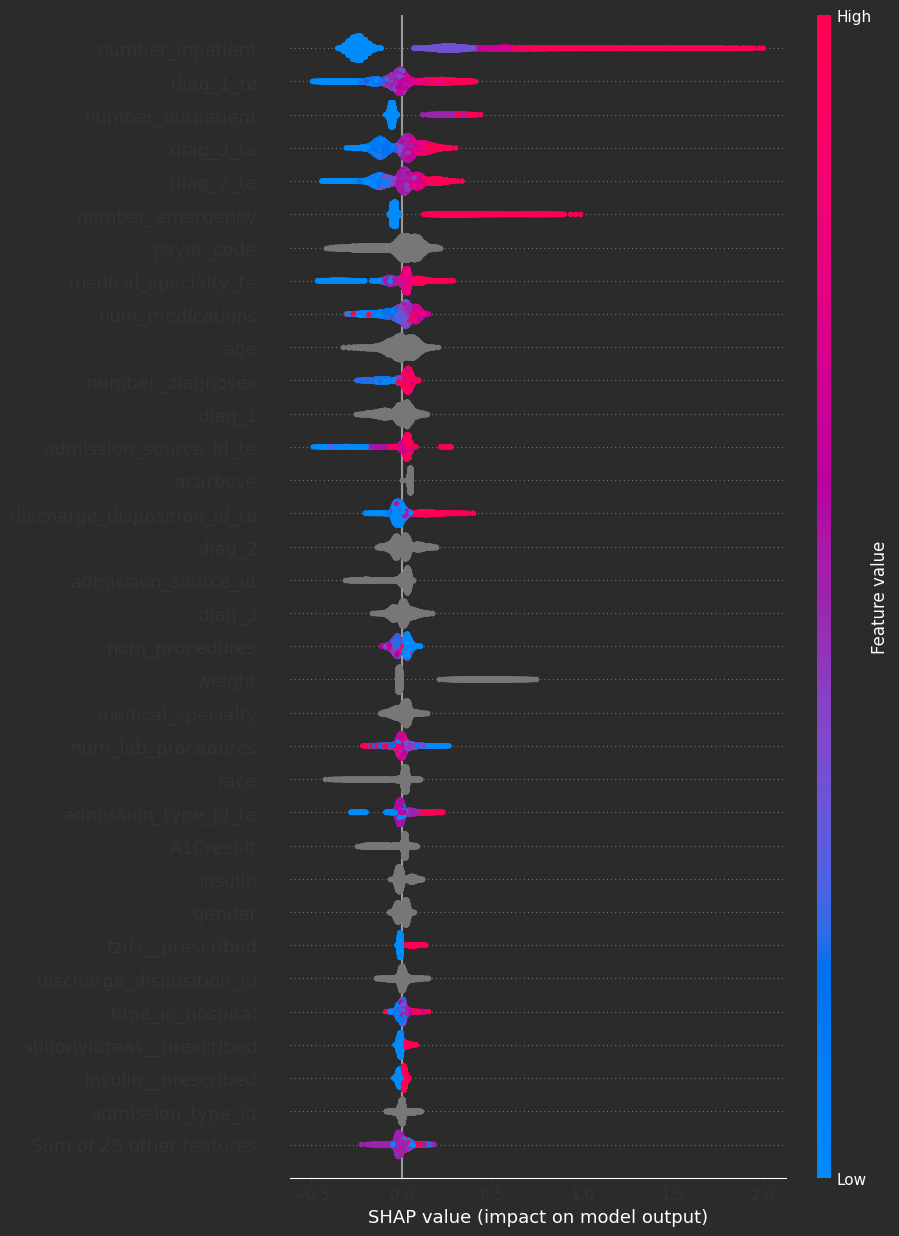

In [28]:
# 4. SHAP Behavior Analysis -------------------------------------------------------------------------------------------

def aggregate_shap_groups(shap_values,
                          feature_names,
                          groups
                          ):
    feature_index = {name: i for i, name in enumerate(feature_names)}
    output = {}

    for group_name, columns in groups.items():
        indices = [feature_index[column] for column in columns if column in feature_index]
        output[group_name] = shap_values.values[:, indices].sum(axis=1)

    return pd.DataFrame(output)

if RUN_SHAP_IMPORTANCE:

    # ----- Importance heatmap

    DICT_SHAP_EXPLAINER = {k: shap.TreeExplainer(v) for k, v in DICT_MODEL_OUTPUT.items() if k != 'm0'}
    DICT_SHAP_EXPLAINER_COLS = {k: v.feature_names_in_ for k, v in DICT_MODEL_OUTPUT.items() if k != 'm0'}
    DICT_SHAP_VALUES = {k: v(X_val[DICT_MODEL_OUTPUT[k].feature_names_in_.tolist()]) for k, v in DICT_SHAP_EXPLAINER.items()}
    for k, v in DICT_SHAP_VALUES.items():
        v.feature_names = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in v.feature_names]

    ls_shap = []
    for k, v in DICT_SHAP_VALUES.items():
        feature_imp = v.abs.mean(axis=0).values
        df_shap = pd.DataFrame({'feature': v.feature_names, k: feature_imp}).set_index('feature')
        ls_shap.append(df_shap)
    df_shap_all = pd.concat(ls_shap, axis=1).sort_values('m9', ascending=False)
    df_shap_all.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_feature_importance.csv')

    with open(PATH_XGB_ANALYSIS / 'ana4_shap_values.pkl', 'wb') as f:
        pickle.dump(DICT_SHAP_VALUES, f)

else:

    with open(PATH_XGB_ANALYSIS / 'ana4_shap_values.pkl', 'rb') as f:
        DICT_SHAP_VALUES = pickle.load(f)

    df_shap_all = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_feature_importance.csv', index_col=0)

# ----- Create beeswarm plot
shap_values = DICT_SHAP_VALUES['m9']
shap.plots.beeswarm(
    shap_values,
    max_display=34,   # selected based on >= 0.01
    group_remaining_features=True,
)


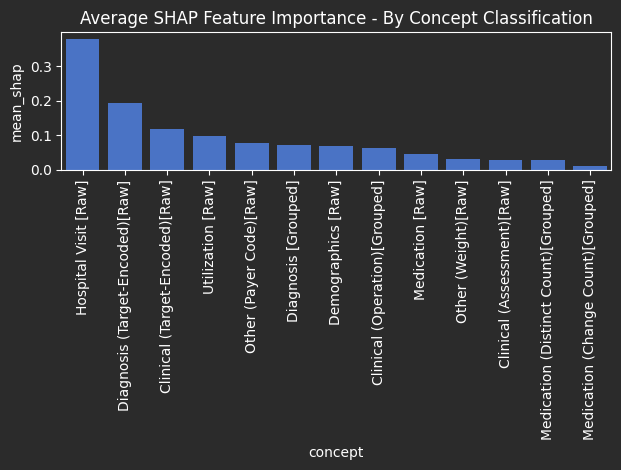

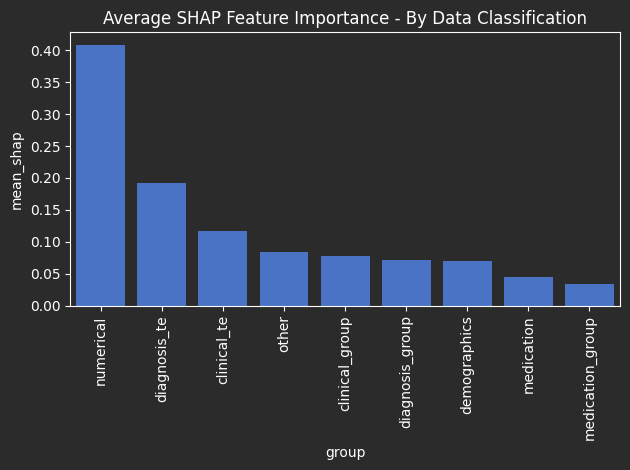

In [19]:
if RUN_SHAP_GROUP:

    # ----- Feature concept groups

    # Define feature groups
    feature_groups_concept_adj = deepcopy(feature_groups_concept)
    for k, v in feature_groups_concept_adj.items():
        feature_groups_concept_adj[k] = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in v]

    # Get feature concept shap
    df_shap_concept = aggregate_shap_groups(shap_values, shap_values.feature_names, feature_groups_concept_adj)
    df_shap_concept.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept.csv', index=False)

    # Get mean feature concept shap
    df_shap_concept_mean = df_shap_concept.mean().sort_values(ascending=False).reset_index()
    df_shap_concept_mean.columns = ['concept', 'mean_shap']
    df_shap_concept_mean.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept_mean.csv', index=False)

    # Get mean abs feature concept shap
    df_shap_concept_mean_abs = df_shap_concept.abs().mean().sort_values(ascending=False).reset_index()
    df_shap_concept_mean_abs.columns = ['concept', 'mean_shap']
    df_shap_concept_mean_abs.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept_mean_abs.csv', index=False)

    # ----- Feature model groups

    feature_groups_model = {
        'numerical': num_cols,
        'demographics': dem_cols,
        'clinical_group': clin_cols,
        'clinical_te': clin_te_cols,
        'diagnosis_group': diag_cols,
        'diagnosis_te': diag_te_cols,
        'medication_group': druggrp_cols,
        'medication': drug_cols,
        'other': other_cols,
    }

    # Define feature groups
    feature_groups_model_adj = deepcopy(feature_groups_model)
    for k, v in feature_groups_model_adj.items():
        feature_groups_model_adj[k] = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in v]

    # Get feature concept shap
    df_shap_model = aggregate_shap_groups(shap_values, shap_values.feature_names, feature_groups_model_adj)
    df_shap_model.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model.csv', index=False)

    # Get mean feature concept shap
    df_shap_model_mean = df_shap_model.mean().sort_values(ascending=False).reset_index()
    df_shap_model_mean.columns = ['group', 'mean_shap']
    df_shap_model_mean.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model_mean.csv', index=False)

    # Get mean abs feature concept shap
    df_shap_model_mean_abs = df_shap_model.abs().mean().sort_values(ascending=False).reset_index()
    df_shap_model_mean_abs.columns = ['group', 'mean_shap']
    df_shap_model_mean_abs.to_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model_mean_abs.csv', index=False)

else:
    df_shap_concept_mean_abs = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept_mean_abs.csv')
    df_shap_concept_mean = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept_mean.csv')
    df_shap_concept = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_concept.csv')
    df_shap_model = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model.csv')
    df_shap_model_mean = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model_mean.csv')
    df_shap_model_mean_abs = pd.read_csv(PATH_XGB_ANALYSIS / 'ana4_shap_model_mean_abs.csv')

ax = sns.barplot(df_shap_concept_mean_abs, x='concept', y='mean_shap')
ax.set_title('Average SHAP Feature Importance - By Concept Classification')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

ax = sns.barplot(df_shap_model_mean_abs, x='group', y='mean_shap')
ax.set_title('Average SHAP Feature Importance - By Data Classification')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Analysis 5: SHAP subgroup dependence analysis

SHAP Dependence Plot (Diagnosis - Grouped)


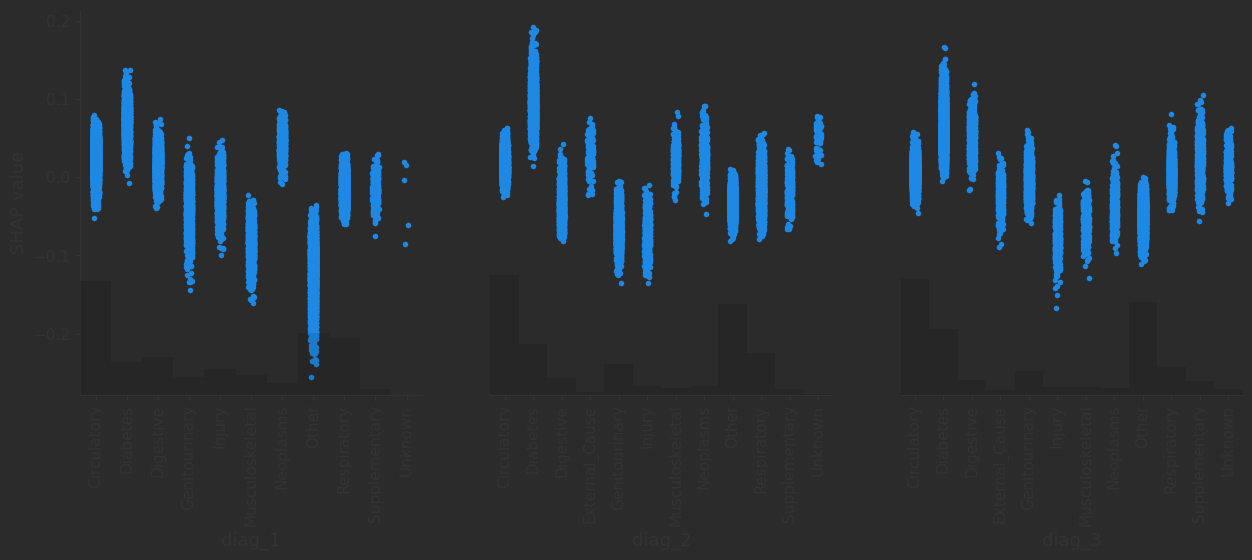



SHAP Dependence Plot (Diagnosis - Target-Encoded)


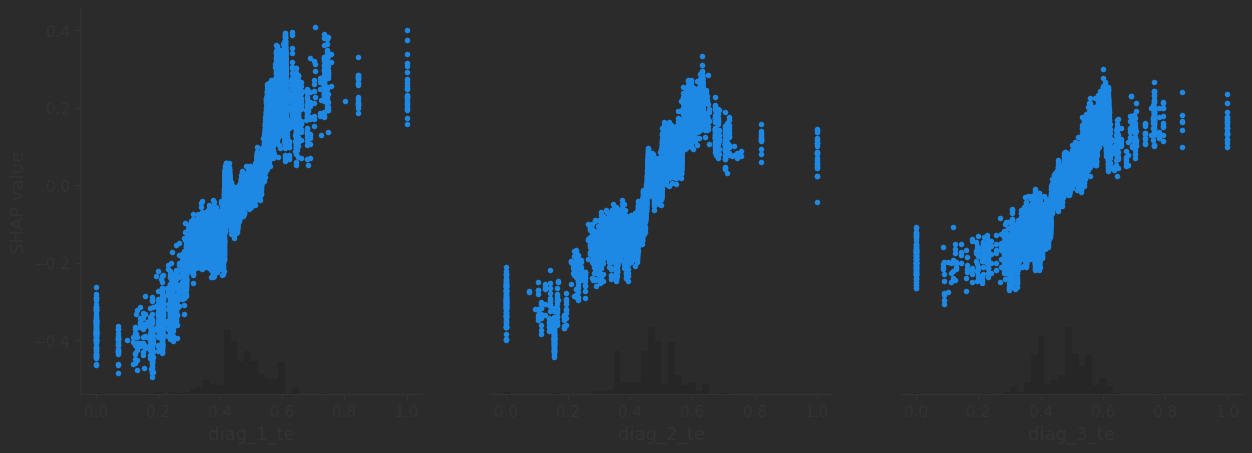



SHAP Dependence Plot (Other)


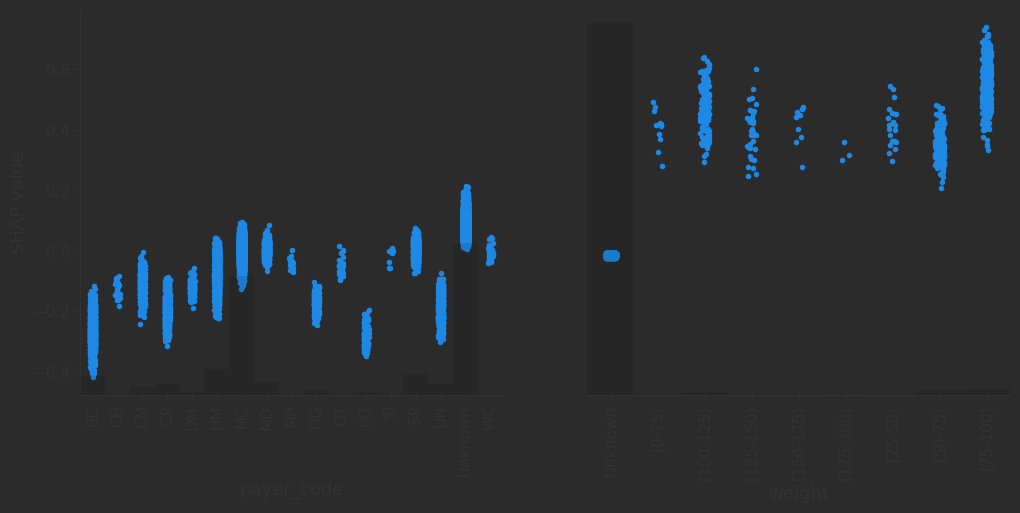



SHAP Dependence Plot (Clinical)


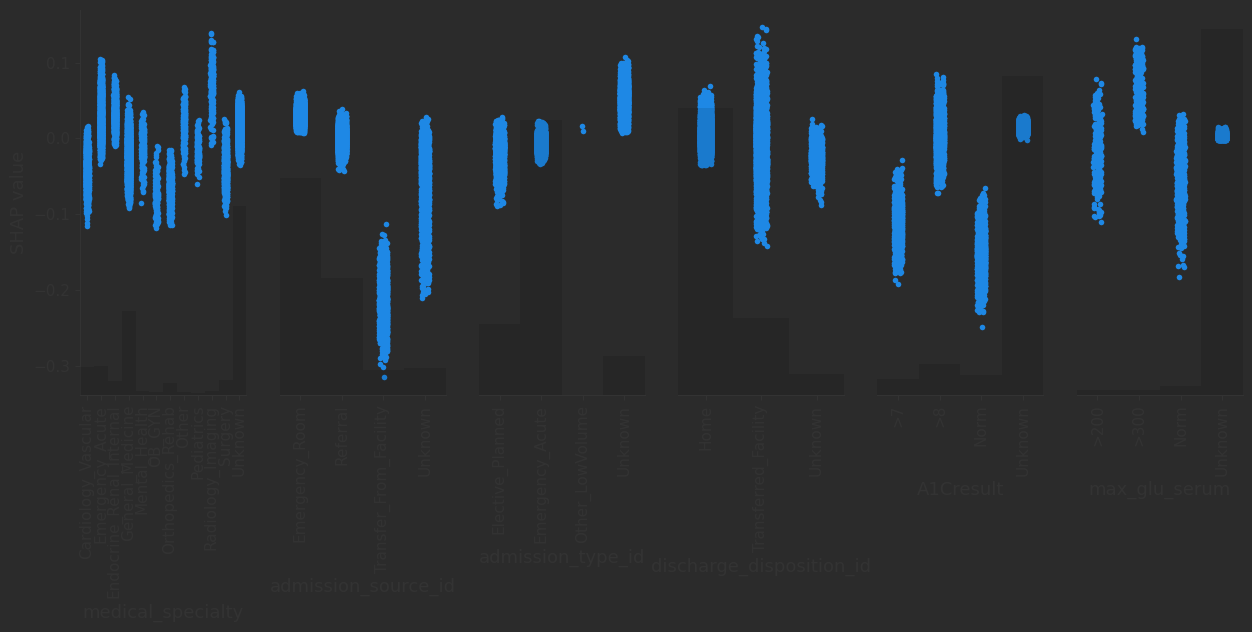



SHAP Dependence Plot (Clinical, Target-Encoded)


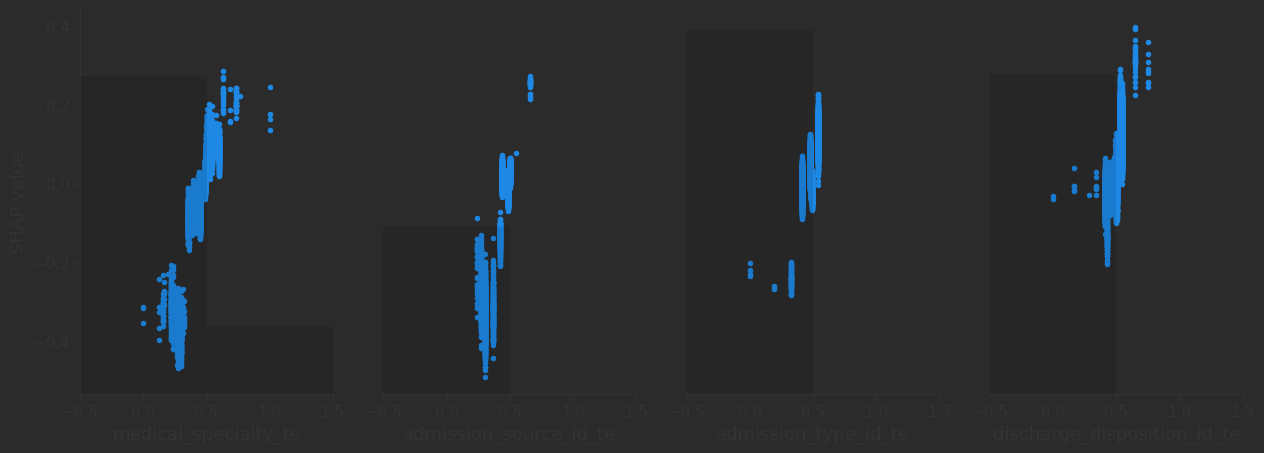



SHAP Dependence Plot (Demographics)


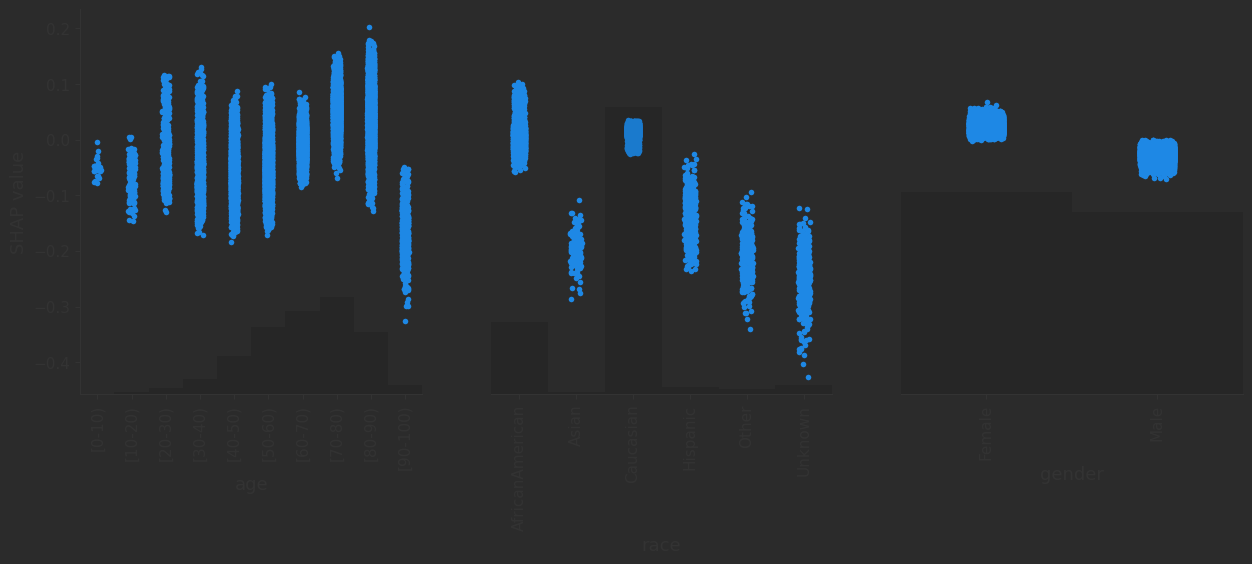



SHAP Dependence Plot (Medication (Grouped)




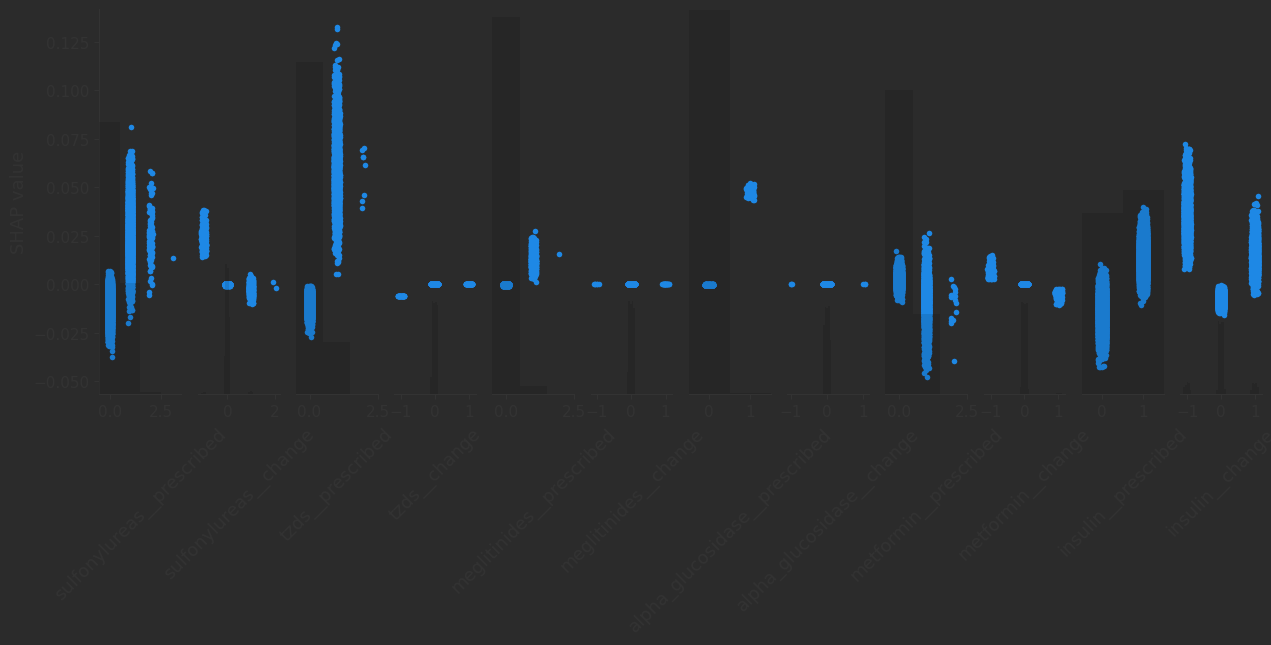

In [27]:
# 5. Subgroup Dependence Analysis -------------------------------------------------------------------------------------------

# Dependency plot
if True:
    print('SHAP Dependence Plot (Diagnosis - Grouped)')
    shap.plots.scatter(shap_values[:, ['diag_1', 'diag_2', 'diag_3']])
    # plt.title('SHAP Dependence Plot (Diagnosis - Grouped)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Diagnosis - Target-Encoded)')
    shap.plots.scatter(shap_values[:, ['diag_1_te', 'diag_2_te', 'diag_3_te']])
    # plt.title('SHAP Dependence Plot (Diagnosis - Target-Encoded)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Other)')
    shap.plots.scatter(shap_values[:, ['payer_code', 'weight']])
    # plt.title('SHAP Dependence Plot (Other)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Clinical)')
    shap.plots.scatter(shap_values[:, ['medical_specialty', 'admission_source_id', 'admission_type_id', 'discharge_disposition_id', 'A1Cresult', 'max_glu_serum']])
    # plt.title('SHAP Dependence Plot (Clinical)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Clinical, Target-Encoded)')
    shap.plots.scatter(shap_values[:, ['medical_specialty_te', 'admission_source_id_te', 'admission_type_id_te', 'discharge_disposition_id_te']])
    # plt.title('SHAP Dependence Plot (Clinical, Target-Encoded)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Demographics)')
    shap.plots.scatter(shap_values[:, ['age', 'race', 'gender']])
    # plt.title('SHAP Dependence Plot (Demographics)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

    print('SHAP Dependence Plot (Medication (Grouped)')
    shap.plots.scatter(shap_values[:, ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in druggrp_cols]], show=False)
    for ax in plt.gcf().axes:
        ax.xaxis.label.set_rotation(45)
    # plt.title('SHAP Dependence Plot (Medication (Grouped)')
    # plt.tight_layout()
    # plt.show()
    print('\n')

### Analysis 6: Residual analysis

In [ ]:
# 6. Residual Analysis -------------------------------------------------------------------------------------------

if RUN_RESIDUAL_ANA:

    # Get last model and data
    k = "m9"
    model = DICT_MODEL_OUTPUT[k]
    x = X_val[model.feature_names_in_]

    explainer_res = dx.Explainer(model, x, y_val, label=k, predict_function=predict_positive_prob, verbose=True)
    resid_diag = explainer_res.model_diagnostics()

    df_resid = resid_diag.result
    df_resid.columns = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_resid.columns]

    df_resid.to_csv(PATH_XGB_ANALYSIS / 'ana6_df_resid.csv', index=False)

    ax = sns.histplot(df_resid.result, x='residuals', bins=100)
    ax.set_title('Histogram of Residuals (M9)')
    plt.tight_layout()
    plt.show()

    # ----------- Demographics

    ax = sns.histplot(df_resid, x='residuals', hue='age', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By age')
    plt.tight_layout()
    plt.show()

    ax = sns.histplot(df_resid, x='residuals', hue='race', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By race')
    plt.tight_layout()
    plt.show()

    ax = sns.histplot(df_resid, x='residuals', hue='gender', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By gender')
    plt.tight_layout()
    plt.show()

    # ----------- Clinical

    ax = sns.histplot(df_resid, x='residuals', hue='medical_specialty', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By medical_specialty')
    plt.tight_layout()
    plt.show()

    # ----------- Diagnosis

    ax = sns.histplot(df_resid, x='residuals', hue='diag_1', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By diag_1')
    plt.tight_layout()
    plt.show()

    df_resid[num_cols_raw] = X_val_interim[num_cols_raw]
    ax = sns.histplot(df_resid, x='residuals', hue='number_inpatient', bins=50, multiple='stack')
    ax.set_title('Histogram of Residuals (M9) - By number_inpatient')
    plt.tight_layout()
    plt.show()

    ax = sns.scatterplot(df_resid, x='residuals', y='number_inpatient')
    ax.set_title('Histogram of Residuals (M9) - By number_inpatient')
    plt.tight_layout()
    plt.show()

else:

    df_resid = pd.read_csv(PATH_XGB_ANALYSIS / 'ana6_df_resid.csv')


dict_resid_stat = dict()
for c in num_cols_raw + dem_cols + clin_cols + diag_cols + other_cols:
    c = '__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c
    dict_resid_stat[c] = (df_resid[[c, 'y', 'residuals', 'abs_residuals']]
                          .groupby([c, 'y'])
                          .agg({'residuals': ['mean', 'median', 'count'], 'abs_residuals': 'mean'}))


### Analysis 7: SHAP interaction analysis

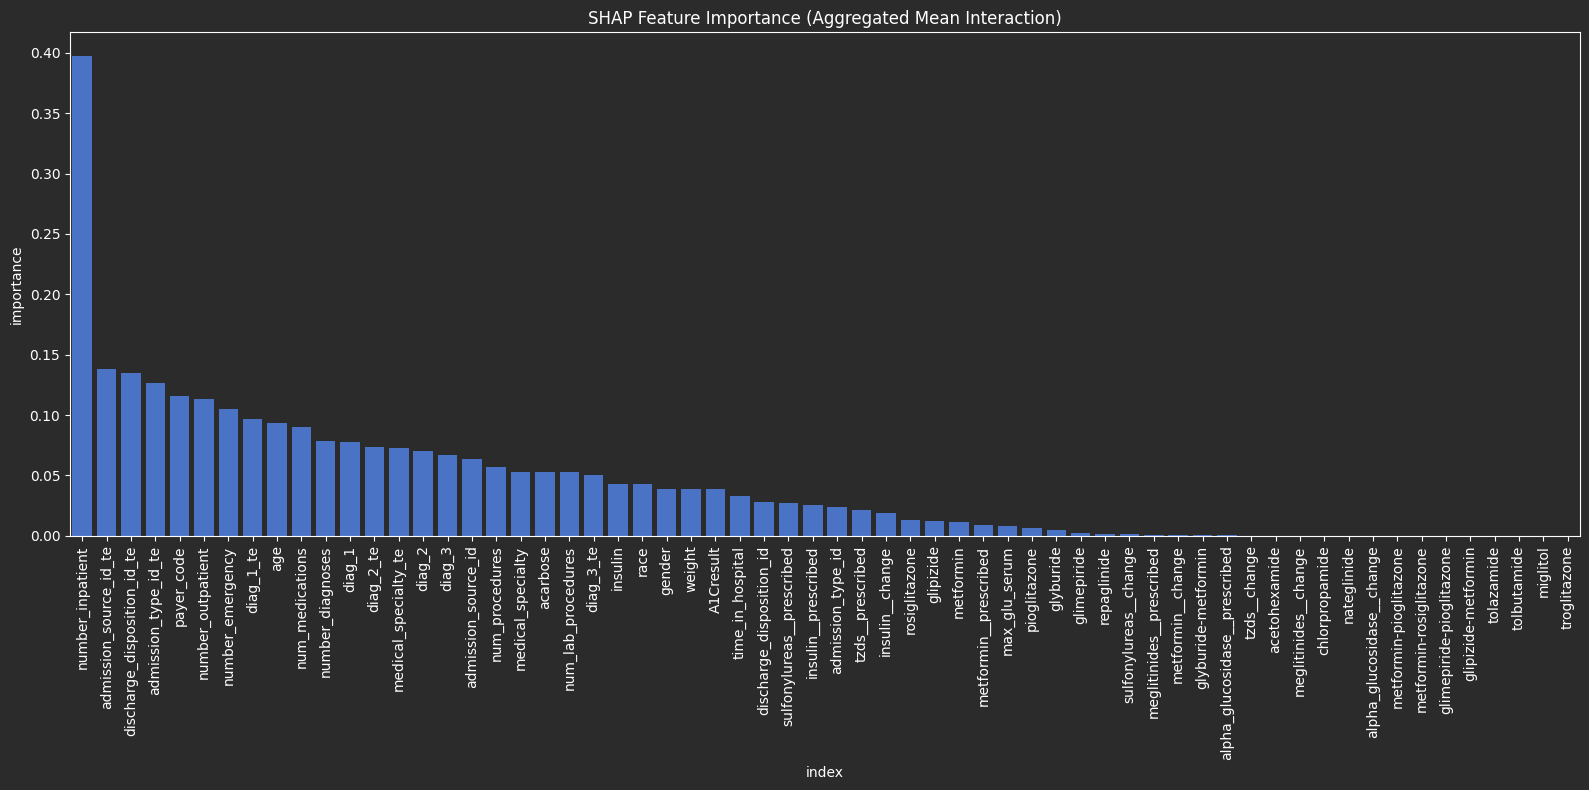

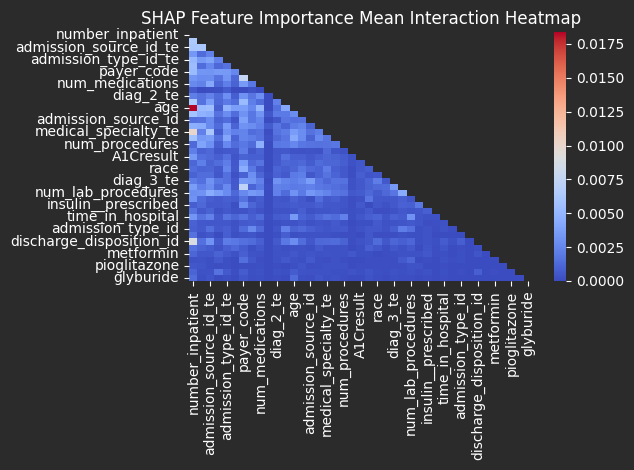

In [7]:
# 7. Interaction Analysis -------------------------------------------------------------------------------------------

if RUN_SHAP_INTERACTION:

    model = DICT_MODEL_OUTPUT['m9']
    X_sample = X_val.loc[:, model.feature_names_in_].sample(5000, random_state=42)
    dmatrix = xgboost.DMatrix(X_sample, enable_categorical=True)
    shap_interaction = model.get_booster().predict(dmatrix, pred_interactions=True)
    shap_interaction_features = shap_interaction[:, :-1, :-1]

    # Calculate SHAP interactions
    features = list(model.feature_names_in_)
    mat_interaction = np.zeros((len(features), len(features)))
    for c1 in DICT_MODEL_OUTPUT['m9'].feature_names_in_:
        for c2 in DICT_MODEL_OUTPUT['m9'].feature_names_in_:
            i = features.index(c1)
            j = features.index(c2)
            mat_interaction[i][j] = np.abs(shap_interaction_features[:, i, j]).mean()

    # SHAP interaction (mean abs main effect + pairwise interaction effect)
    df_interaction = pd.DataFrame(mat_interaction, index=features, columns=features)
    df_interaction.index = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_interaction.index]
    df_interaction.columns = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_interaction.columns]

    # Feature interaction importance
    diag = np.diag(mat_interaction)
    interaction_importance = diag + 0.5 * (mat_interaction.sum(axis=1) - diag)
    df_interaction_imp = pd.DataFrame(interaction_importance, index=features, columns=['importance']).sort_values(by='importance', ascending=False)
    df_interaction_imp.index = ['__'.join(c.split('__')[1:]) if len(c.split('__')) > 1 else c for c in df_interaction_imp.index]

    order = np.argsort(np.diag(df_interaction))[::-1]
    df_interaction = df_interaction.iloc[order, order]

    with open(PATH_XGB_ANALYSIS / 'ana7_shap_interaction.pkl', 'wb') as f:
        pickle.dump(shap_interaction_features, f)

    df_interaction.to_csv(PATH_XGB_ANALYSIS / 'ana7_shap_interaction_df.csv')

    df_interaction_imp.to_csv(PATH_XGB_ANALYSIS / 'ana7_shap_interaction_imp_df.csv')

else:
    with open(PATH_XGB_ANALYSIS / 'ana7_shap_interaction.pkl', 'rb') as f:
        shap_interaction_features = pickle.load(f)

    df_interaction = pd.read_csv(PATH_XGB_ANALYSIS / 'ana7_shap_interaction_df.csv', index_col=0)

    df_interaction_imp = pd.read_csv(PATH_XGB_ANALYSIS / 'ana7_shap_interaction_imp_df.csv', index_col=0)

plt.figure(figsize=(16, 8))
ax = sns.barplot(df_interaction_imp.reset_index(), x='index', y='importance')
ax.set_title('SHAP Feature Importance (Aggregated Mean Interaction)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

df_interaction_copy = df_interaction.copy()
idx = np.diag(df_interaction) > 0.001
df_interaction_copy = df_interaction_copy.loc[idx, idx]
mask = np.triu(np.ones_like(df_interaction_copy, dtype=bool))
df_interaction_copy = df_interaction_copy.mask(np.eye(df_interaction_copy.shape[0], dtype=bool))
ax = sns.heatmap(df_interaction_copy, mask=mask, cmap='coolwarm')
ax.set_title('SHAP Feature Importance Mean Interaction Heatmap')
plt.tight_layout()
plt.show()
